In [207]:
# importing librwaries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [208]:
# Load Dataset

df = pd.read_csv(r'C:\Users\Admin\Documents\Cafe_Sales_Analysis\dirty_cafe_sales.csv')

In [209]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [210]:
df.shape

(10000, 8)

In [211]:
df.columns 

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [213]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [214]:
# Data Cleaning

In [215]:
# checking for the  missing values 
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [217]:
df['Quantity'].value_counts()

Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64

In [218]:
# Since the Quantity column contains 171 unknown values and 170 ERROR values we need to first convert 
# them to  nan 

# Replacing invalid values with the NaN

df['Quantity'].replace(['UNKNOWN','ERROR'],np.nan,inplace = True)

In [219]:
df['Quantity'].value_counts()

# Now all the irrealvent values are converted to nan 

Quantity
5    2013
2    1974
4    1863
3    1849
1    1822
Name: count, dtype: int64

In [220]:
# Lets convert the quantity column to numeric datatype 

df['Quantity'] = pd.to_numeric(df['Quantity'],errors = 'coerce')

In [221]:
# checking the datatype of the Quantity column

df['Quantity'].dtype

# So we have successfully coverted the datatype of the column from the object to  float datatype 

dtype('float64')

In [222]:
# Filling the missing values 

df['Quantity'].fillna(df['Quantity'].median(),inplace =True)

In [223]:
# checking for the missing values in the quantity column 
df['Quantity'].isnull().sum()

np.int64(0)

In [224]:
# Converting the column to string to remove extra spaces to handle inconsistent formatting which can cause 
# error during type conversion or anlaysis 

df['Price Per Unit'] = df['Price Per Unit'].astype('str').str.strip()
df['Total Spent'] = df['Total Spent'].astype('str').str.strip()



In [225]:
# Converting the numerical columns with object datatype  to numeric datatype and handling the mmissing values 

cols = ['Price Per Unit','Total Spent']

for col in cols:
    df[col] = df[col].astype('str').str.strip()  # removing spaces 
    df[col]= pd.to_numeric(df[col],errors = 'coerce') # covert to numeric
    df[col].fillna(df[col].median(),inplace = True)

In [226]:
# Verifying the datatypes of the column

df.info()

# We have successfullu changed the datatypes of the columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          10000 non-null  float64
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       10000 non-null  float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [227]:
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

In [228]:
# Since the Item column contains irrelavent values 
# so in order to handle those irrelavent value first we need to convert those values to nan and then replace the 
# nan value with the mode

df['Item'] = df['Item'].replace(['UNKNOWN','ERROR'],np.nan)

In [229]:
# Handling the missing values of the categoruical column 

cols = ['Item','Payment Method','Location']

for col in cols:
     df[col] = df[col].astype('str').str.strip()
     df[col] = df[col].fillna(df[col].mode()[0])

In [230]:
df.isnull().sum()


# Missing values of all the columns except Transaction Date is handled   

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    159
dtype: int64

In [231]:
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
nan          969
Name: count, dtype: int64

In [232]:
df['Item'] = df['Item'].replace('nan',np.nan)

In [233]:
df = df.dropna(subset = ['Item'])

In [234]:
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

In [235]:
# Now lets handle missing values of the Transaction Date column 
# To handle the missing values of the transaction date column first we need to convert the datatype of column to date datatype 

#df['Transaction Date'] = pd.to_datetime(df['Transaction Date'],format = '')

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'],errors = 'coerce')

In [284]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Year                0
Month               0
Day                 0
Weekday             0
dtype: int64

In [237]:
df['Transaction Date'].isna().sum()

np.int64(418)

In [238]:
# dropping the missing values from the date column 

df = df.dropna(subset =['Transaction Date'])

In [239]:
df['Transaction Date'].isna().sum()

# No nan values in the Transaction Date column 


np.int64(0)

In [240]:
# Checking for the duplicates 

df.duplicated().sum()

# No duplicates in the dataset 

np.int64(0)

# Feature Engineering 

In [241]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Weekday'] = df['Transaction Date'].dt.day_name()

In [242]:
# checking for the newly created columns 

df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Year', 'Month',
       'Day', 'Weekday'],
      dtype='object')

# Univariate Analysis

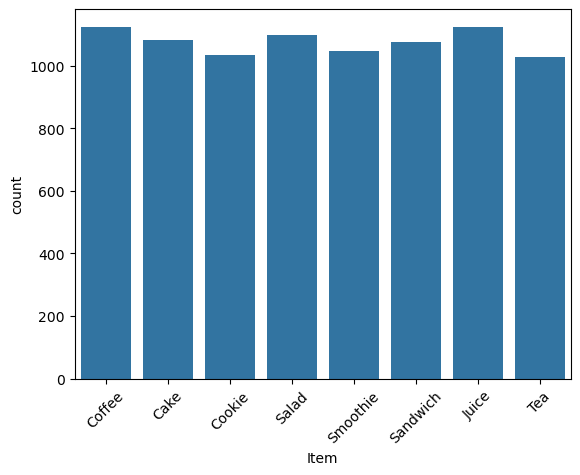

In [243]:
sns.countplot(x = 'Item',data = df)
plt.xticks(rotation =45) 
plt.show()


### Insight:
- Coffee is the most frequently sold item.
- Tea and snacks follow but with lower demand.

In [244]:
df['Payment Method'].value_counts()

Payment Method
nan               2203
Digital Wallet    1980
Cash              1956
Credit Card       1949
ERROR              276
UNKNOWN            249
Name: count, dtype: int64

In [245]:
df['Payment Method'] = df['Payment Method'].replace(['ERROR','UNKNOWN'],np.nan)

In [246]:
df['Payment Method'].isnull().sum()

np.int64(525)

In [247]:
df['Payment Method'] = df['Payment Method'].replace(['nan'],np.nan)

In [248]:
df['Payment Method'] = df['Payment Method'].fillna('Missing')

In [249]:
df['Payment Method'].value_counts()

Payment Method
Missing           2728
Digital Wallet    1980
Cash              1956
Credit Card       1949
Name: count, dtype: int64

<Axes: xlabel='Payment Method', ylabel='count'>

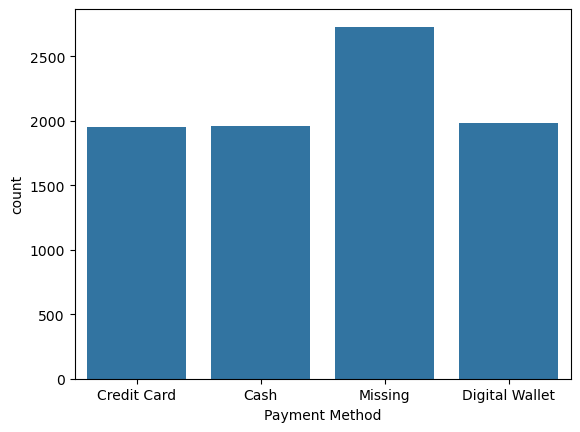

In [250]:
# Visualizing Payment Method Distribution 

sns.countplot(x = 'Payment Method',data = df)

# Insight 
Most of the payments are made thorugh missing payment method whereas other payment methods i.e Credit Card,Cash and Digital Wallet 
are eveny distributed 

In [251]:
df['Location'].value_counts()

Location
nan         2818
Takeaway    2603
In-store    2587
ERROR        310
UNKNOWN      295
Name: count, dtype: int64

In [273]:
df['Location'].head(200)

0      Takeaway
1      In-store
2      In-store
3       Missing
4      In-store
5           NaN
7       Missing
9      In-store
10     Takeaway
12     In-store
13     Takeaway
15     In-store
16          NaN
17     In-store
18      Missing
19     Takeaway
20     In-store
21     Takeaway
22     Takeaway
23          NaN
24     In-store
25      Missing
26     In-store
27     Takeaway
28          NaN
32     In-store
34     Takeaway
35      Missing
37     In-store
38     Takeaway
39          NaN
40     In-store
41     Takeaway
42     Takeaway
43     Takeaway
44          NaN
45          NaN
46     In-store
47          NaN
48          NaN
49      Missing
50     Takeaway
51     Takeaway
53          NaN
54     Takeaway
55     Takeaway
56     Takeaway
57     In-store
58     Takeaway
59     In-store
60          NaN
62          NaN
64          NaN
65     In-store
66          NaN
67     Takeaway
68     In-store
70     In-store
71     In-store
73      Missing
74      Missing
75     Takeaway
76      

In [275]:
df['Location'].isna().any()

np.True_

In [271]:
df['Location'].isna().sum()

np.int64(2818)

In [252]:
df['Location'] = df['Location'].replace('nan',np.nan)
df['Location'] = df['Location'].replace(['ERROR','UNKNOWN'],'Missing')

In [253]:
df['Location'].value_counts()

Location
Takeaway    2603
In-store    2587
Missing      605
Name: count, dtype: int64

In [276]:
df['Location']=df['Location'].fillna(df['Location'].mode()[0])

In [277]:
df['Location'].isna().sum()

np.int64(0)

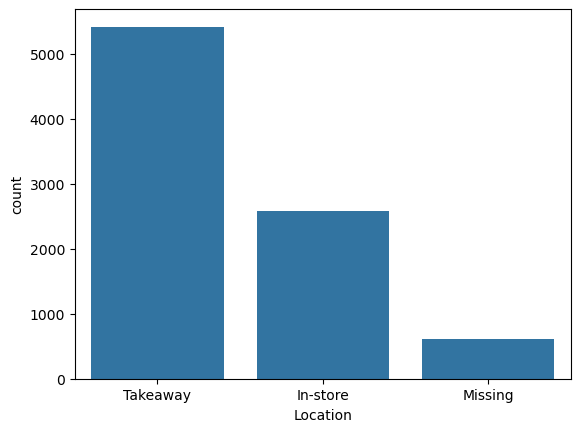

In [280]:
# Visualizing Location distribution 

sns.countplot(x = 'Location',data = df)
plt.show()

In [255]:
# Insights 
# “The majority of transactions are takeaway, indicating a strong preference for convenience-based purchases. 
# In-store orders are significantly lower, suggesting limited dine-in engagement. 
# Additionally, a small portion of missing data highlights a data quality issue that should be addressed.”

# Bivariate Analysis 

In [256]:
# Most sold items 

df.groupby('Item')['Quantity'].sum().sort_values(ascending = False)

# Insights 
# So as you can see all the products sales are approximately same indicating balanced demand accross balanced prodeucts.
#coffee is the most sold item whereas cookie is the lowest sold item.

Item
Coffee      3425.0
Juice       3351.0
Salad       3314.0
Cake        3278.0
Sandwich    3266.0
Smoothie    3208.0
Tea         3125.0
Cookie      3093.0
Name: Quantity, dtype: float64

In [257]:
# location wise sales 

df.groupby('Location')['Quantity'].sum()



Location
In-store    7844.0
Missing     1789.0
Takeaway    7890.0
Name: Quantity, dtype: float64

Takeaway and in-store sales contribute almost equally to total quantity, indicating balanced customer behavior across both channels.
There is no strong preference for a specific purchase mode, suggesting both channels are equally important for business operations.
A considerable portion of transactions lacks location information, which may impact the accuracy of location-based analysis.

Businesses should equally focus on optimizing both takeaway and in-store services, as both contribute similarly to total sales.

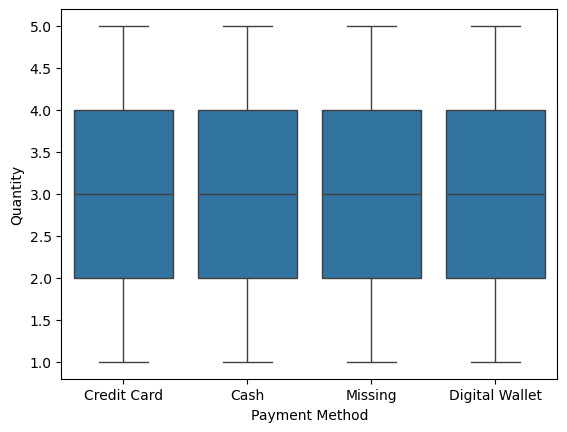

In [281]:
sns.boxplot(x = 'Payment Method',y = 'Quantity',data = df)
plt.show()

The variability in quantity is similar across all payment methods, indicating consistent purchasing patterns.
no exptreme points visible 
There are no significant outliers in quantity across payment method 
The choice of payment method does not appear to influence the quantity purchased by customers.

# Time Series Analaysis

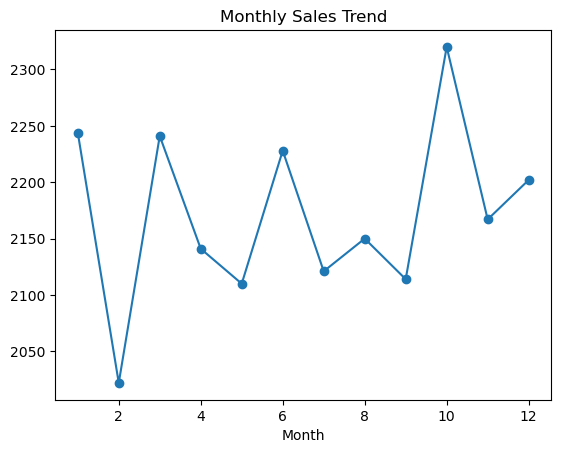

In [282]:
# Visualizing Monthly sales trend 

monthly_sales = df.groupby('Month')['Quantity'].sum()

monthly_sales.plot(kind = 'line',marker = 'o')
plt.title("Monthly Sales Trend")
plt.show()



so as you can see in the above graph the sales is hihghest  in 10th  month whereas lowest in 2nd month.

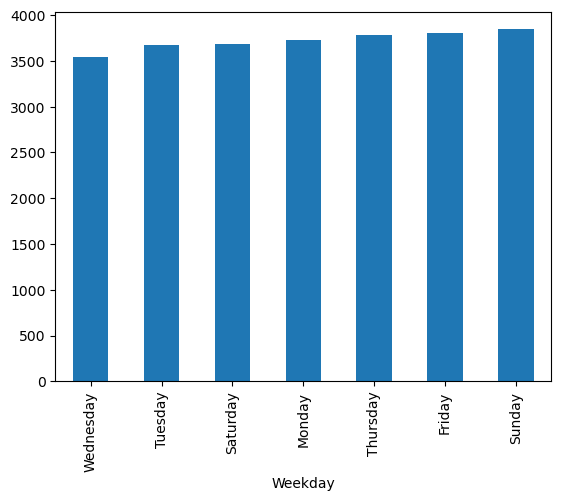

In [260]:
# Weekly Sales 

df.groupby('Weekday')['Quantity'].sum().sort_values().plot(kind = 'bar')
plt.show()

Insights 
The visualization shows that total quantity sold remains relatively consistent across all days, with only slight variations.
There is a mild increasing trend, but no significant spikes or drops are observed.
This indicates stable and predictable customer demand, with no strong day-wise effect on sales.

In [283]:
# Top performing Combinations 

df.groupby(['Item','Location'])['Quantity'].sum().unstack()

Location,In-store,Missing,Takeaway
Item,,,
Cake,937.0,285.0,2056.0
Coffee,922.0,226.0,2277.0
Cookie,928.0,200.0,1965.0
Juice,1053.0,183.0,2115.0
Salad,1073.0,213.0,2028.0
Sandwich,1084.0,225.0,1957.0
Smoothie,909.0,239.0,2060.0
Tea,938.0,218.0,1969.0


Insight
The analysis of item-wise sales across locations shows that most items, such as Coffee, Cake, and Cookies, are slightly more popular
in takeaway orders.
However, items like Juice, Salad, and Sandwich exhibit higher sales in in-store transactions, indicating a preference for consuming meal-type items
on-site. Missing location data is present but relatively small compared to valid categories, ensuring the reliability of the analysis. 
Overall, the data

In [263]:
df['Item'].value_counts()

Item
Juice       1124
Coffee      1123
Salad       1099
Cake        1082
Sandwich    1075
Smoothie    1048
Cookie      1035
Tea         1027
Name: count, dtype: int64

In [279]:
# Saving the file to the system 

df.to_csv(r'C:\Users\Admin\Documents\Cafe_Sales_Analysis\new_cleaned_data1.csv',index = False)